In [1]:
from cube_nn import CubeValueResNet
from training import train_on_value_dataset
from torch import optim
import matplotlib.pyplot as plt
import torch
from cube_nn import NNValueFunctionType
from cube_datasets import TrainingValueDataset

device = "cuda"

In [2]:
name = 'resnet2.2'

# Load a previously saved net
I_NET = 500
net = CubeValueResNet()
net.load_state_dict(torch.load(f'temp_models/{name}/cube_value_resnet_iter_{I_NET}.pth'))

/tmp/ipykernel_316824/3784450186.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(f'temp_models/{name}/cube_value_resnet_iter_{I_NET}.pth')

<All keys matched successfully>

In [3]:
N_ROLLOUTS = 1000
N_MOVES_MAX = 30

dataset = TrainingValueDataset.create_from_trajectories(
        net.get_cube_to_tensor(),
        N_ROLLOUTS, 
        N_MOVES_MAX, 
        device="cpu",
    )

In [4]:
# Estimate values for all cubes in the dataset
import numpy as np

net.eval()
net.to(device)

# Group cubes by number of moves
cubes_by_moves = {}
for i in range(N_MOVES_MAX + 1):
    cubes_by_moves[i] = []

# Organize cubes by their number of moves
for cube_tensor, value in dataset:
    cubes_by_moves[value.item()].append(cube_tensor)

# Estimate values for each group
move_numbers = []
avg_values = []
std_values = []
min_values = []
max_values = []

with torch.no_grad():
    for moves in sorted(cubes_by_moves.keys()):
        if len(cubes_by_moves[moves]) > 0:
            # Stack all cubes for this move count
            cube_batch = torch.stack(cubes_by_moves[moves]).to(device)
            
            # Get predictions
            predictions = net(cube_batch).cpu().numpy().flatten()
            
            # Calculate statistics
            move_numbers.append(moves)
            avg_values.append(np.mean(predictions))
            std_values.append(np.std(predictions))
            min_values.append(np.min(predictions))
            max_values.append(np.max(predictions))

print(f"Processed {len(move_numbers)} different move counts")
print(f"Total cubes analyzed: {sum(len(cubes_by_moves[m]) for m in cubes_by_moves)}")

Processed 30 different move counts
Total cubes analyzed: 30000


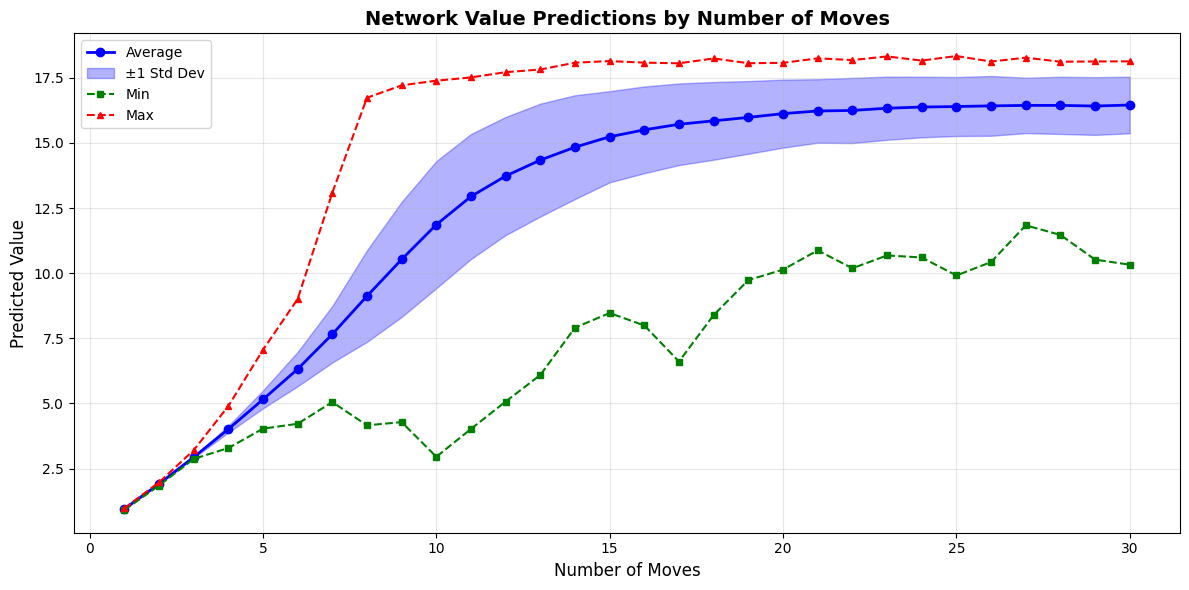

In [5]:
%matplotlib inline

# Combined plot with all statistics
plt.figure(figsize=(12, 6))

plt.plot(move_numbers, avg_values, marker='o', linewidth=2, markersize=6, label='Average', color='blue')
plt.fill_between(move_numbers, 
                 [avg - std for avg, std in zip(avg_values, std_values)],
                 [avg + std for avg, std in zip(avg_values, std_values)],
                 alpha=0.3, color='blue', label='±1 Std Dev')
plt.plot(move_numbers, min_values, marker='s', linewidth=1.5, markersize=5, label='Min', color='green', linestyle='--')
plt.plot(move_numbers, max_values, marker='^', linewidth=1.5, markersize=5, label='Max', color='red', linestyle='--')

plt.xlabel('Number of Moves', fontsize=12)
plt.ylabel('Predicted Value', fontsize=12)
plt.title('Network Value Predictions by Number of Moves', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the figure
plt.savefig(f'figs/{name}/prediction_analysis_{I_NET}.png', dpi=300, bbox_inches='tight')

plt.show()
